# Introduction

This notebook documents group 1's project following the CRISP-DM process.

# Business Understanding

Here you need to state the business problem you are working on, including all the questions that fall into this category like why it is useful, who will use it, when is it due, how should it be deployed, etc. The business problem itself should be one sentence, then add the background and answers to the question.

In [39]:
print("Business problem: Which Audio Features are Most Closely Tied to Song Popularity?")

print("Who will use it: Producers, Artists, Record Labels, Steaming Platforms")

print("When is it due: End of the quarter")

print("How should it be deployed: Presentation and final report")

print("Business problem itself: Predict popularity based on audio features in a song.")


Business problem: Which Audio Features are Most Closely Tied to Song Popularity?
Who will use it: Producers, Artists, Record Labels, Steaming Platforms
When is it due: End of the quarter
How should it be deployed: Presentation and final report
Business problem itself: Predict popularity based on audio features in a song.


In [40]:
# You can build a dataframe of prior modeling approaches from the literature here.
# For each approach, include the model type, the features used (short list of most important ones), the results, and the strengths and weaknesses of each one.

# Example dataframe of prior modeling approaches

import pandas as pd

print("Prior Modeling Approaches")

data = {
    "Model Type": ["Linear Regression", "Random Forest", "Neural Network"],
    "Short list or description of features Used": [
        "Feature1, Feature2, Feature3",
        "Feature1, Feature2, Feature4, Feature5",
        "Feature1, Feature3, Feature6"
    ],
    "Results": ["Use short phrases to describe results","Use short phrases to describe results","Use short phrases to describe results"],
    "References": [
        "Doe et al., 2020",
        "Smith et al., 2019",
        "Johnson et al., 2021"
    ]
}

prior_models_df = pd.DataFrame(data)
prior_models_df

Prior Modeling Approaches


,Model Type,Short list or description of features Used,Results,References
0,Linear Regression,"Feature1, Feature2, Feature3",Use short phrases to describe results,"Doe et al., 2020"
1,Random Forest,"Feature1, Feature2, Feature4, Feature5",Use short phrases to describe results,"Smith et al., 2019"
2,Neural Network,"Feature1, Feature3, Feature6",Use short phrases to describe results,"Johnson et al., 2021"


In [41]:
# Here you can brainstorm the inputs and outputs of your model
# Inputs: List the features you plan to use as inputs to your model
# Outputs: Describe what your model will predict or classify

print("Model Inputs and Outputs")

model_inputs = ["Feature1", "Feature2", "Feature3", "Feature4"]
model_outputs = ["Churn Probability", "Churn Classification"]

print("Inputs:", model_inputs)
print("Outputs:", model_outputs)

Model Inputs and Outputs
Inputs: ['Feature1', 'Feature2', 'Feature3', 'Feature4']
Outputs: ['Churn Probability', 'Churn Classification']


In [42]:
# Here, you can describe the modeling approach you plan to take
# Model Type: Specify the type of model you plan to use (e.g., Logistic Regression, Decision Tree, etc.)
# Features Used: List the features you plan to use in your model
# Expected Results: Describe what you expect to achieve with your model
# Justification: Explain why you chose this modeling approach

print("Planned Modeling Approach")

planned_model = {
    "Model Type": "Supervised Learning - Classification - Random Forest",
    "Features Used": ["Feature1", "Feature2", "Feature4"],
    "Expected Results": "High accuracy in predicting churn",
    "Justification": "Random Forest is robust to overfitting and can handle complex interactions between features."
}

for key, value in planned_model.items():
    print(f"{key}: {value}")    

Planned Modeling Approach
Model Type: Supervised Learning - Classification - Random Forest
Features Used: ['Feature1', 'Feature2', 'Feature4']
Expected Results: High accuracy in predicting churn
Justification: Random Forest is robust to overfitting and can handle complex interactions between features.


In [43]:
# Here you can describe the metrics you will use to evaluate your model
# Metrics: List the metrics you will use to evaluate your model (e.g., Accuracy, Precision, Recall, F1 Score, RMSE, etc.)
# Justification: Explain why you chose these metrics

print("Model Evaluation Metrics")

evaluation_metrics = {
    "Metrics": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Justification": "Your description of why the metrics are important."
}

for key, value in evaluation_metrics.items():
    print(f"{key}: {value}")

Model Evaluation Metrics
Metrics: ['Accuracy', 'Precision', 'Recall', 'F1 Score']
Justification: Your description of why the metrics are important.


### Questions

👀 Is there anything missing from above that I described as part of the Business understanding approach in class?

👀 If so, how might you add it to this notebook?

____________________

# Data Understanding

This section is about understand what data you have:

- What dataset names
- What the pedigree of each dataset is
- What your assumptions about each dataset are

At this point, you are not focused on what features you have or what the data issues are, you will deal with that in the next section. You will need to describe this all in your final report, so go ahead and record it here for reference.

In [44]:
# Describe what you understand about the data you have and need to acquire
# Data Sources: List the data sources you have and any additional data you need to acquire
# Data Pedigree: Describe the pedigree of your data sources (e.g., reliability, validity, etc.)
# Assumptions: List any assumptions you are making about the data

print("Data Understanding")

data_understanding = {
    "Data Sources": ["Customer Database", "Transaction Records", "Customer Support Logs"],
    "Data Pedigree": "The customer database is reliable and regularly updated. Transaction records are accurate but may have missing values. Customer support logs are unstructured and may require preprocessing.",
    "Assumptions": ["Assuming all customers have unique IDs", "Assuming transaction records are complete for the last year"]
}

for key, value in data_understanding.items():
    print(f"{key}: {value}")

Data Understanding
Data Sources: ['Customer Database', 'Transaction Records', 'Customer Support Logs']
Data Pedigree: The customer database is reliable and regularly updated. Transaction records are accurate but may have missing values. Customer support logs are unstructured and may require preprocessing.
Assumptions: ['Assuming all customers have unique IDs', 'Assuming transaction records are complete for the last year']


### Questions

👀 What did you base your assumptions on and what was difficult about doing that?

👀 What if your assumptions are wrong, how might that affect your modeling and results?

👀 What were you able to say about the pedigree of the data: where it came from and how reliable the source was?

_______________

# Data Preparation

Now you have the data you need, and you need to get it into shape for analysis. You have been given three datasets: spotify, songs, and large_set. Most of your data preparation here will have to do with merging and deduplication of the datasets so that you end up with one single dataframe to analyze. There are a lot of decisions you'll make along the way: this is where you really should use this notebook to log each thing you do to the data, and why you did it.

### Import libraries and set file path

In [45]:
# Import necessary libraries
from pathlib import Path                # For handling file paths
import re                               # For regular expressions  
from IPython.display import display     # For displaying dataframes nicely in Jupyter
import re                               # For regular expressions
from difflib import SequenceMatcher     # For string similarity comparison
import numpy as np                      # For numerical operations

# Specify path, use 'r' before path to specify 'raw' path or Python will misread backslashes.
file_loc = Path(r'/workspaces/group-project-dl-team-1/data')

# Check to see if path is legit
print(file_loc.is_dir())

True


### Import and inspect dataframes

In [46]:
# Now we can import our dataframes
spotify = pd.read_csv(file_loc/"spotify_songs.csv")
songs = pd.read_csv(file_loc/"songs.csv")
large_set = pd.read_csv(file_loc/"large_set.csv", engine="python", on_bad_lines="skip")

# Take a look at the dataframes shape (rows, columns) and the column names
print("spotify", spotify.shape, spotify.columns)
print("songs", songs.shape, songs.columns)
print("large_set", large_set.shape, large_set.columns)

spotify (32833, 23) Index(['track_id', 'track_name', 'track_artist', 'track_popularity',
       'track_album_id', 'track_album_name', 'track_album_release_date',
       'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms'],
      dtype='object')
songs (81656, 19) Index(['acousticness', 'artists', 'danceability', 'duration_ms', 'energy',
       'explicit', 'id', 'instrumentalness', 'key', 'liveness', 'loudness',
       'mode', 'name', 'popularity', 'release_date', 'speechiness', 'tempo',
       'valence', 'year'],
      dtype='object')
large_set (396610, 16) Index(['Artist(s)', 'song', 'Length', 'Genre', 'release month', 'release year',
       'Key', 'Tempo', 'Loudness ()', 'Explicit', 'Popularity', 'Energy',
       'Danceability', 'Positiveness', 'Speechiness', 'Liveness'],
      dtype='object')


### Initial Check for missing values

In [47]:
print("\nTotal missing values:")
print("spotify:", spotify.isnull().sum().sum())
print("songs:", songs.isnull().sum().sum())
print("large_set:", large_set.isnull().sum().sum())

# Missing values per column
print("\nMissing values per column (spotify):")
print(spotify.isnull().sum()[spotify.isnull().sum() > 0])

print("\nMissing values per column (songs):")
print(songs.isnull().sum()[songs.isnull().sum() > 0])

print("\nMissing values per column (large_set):")
print(large_set.isnull().sum()[large_set.isnull().sum() > 0])



Total missing values:
spotify: 15
songs: 0
large_set: 7

Missing values per column (spotify):
track_name          5
track_artist        5
track_album_name    5
dtype: int64

Missing values per column (songs):
Series([], dtype: int64)

Missing values per column (large_set):
song    7
dtype: int64


### Questions

👀 What is similar about these datasets?

👀 What is different about these datasets?

💡Not all of these datasets have the same songs...how can we tell, and how will you merge them?

💡Several have the same names for columns...does this mean that the data in those columns is the same for matching songs? How will you determine this?

_______________________________________

### Explore columns

In [48]:
spotify.head(2).T

,0,1
track_id,6f807x0ima9a1j3VPbc7VN,0r7CVbZTWZgbTCYdfa2P31
track_name,I Don't Care (with Justin Bieber) - Loud Luxur...,Memories - Dillon Francis Remix
track_artist,Ed Sheeran,Maroon 5
track_popularity,66,67
track_album_id,2oCs0DGTsRO98Gh5ZSl2Cx,63rPSO264uRjW1X5E6cWv6
track_album_name,I Don't Care (with Justin Bieber) [Loud Luxury...,Memories (Dillon Francis Remix)
track_album_release_date,2019-06-14,2019-12-13
playlist_name,Pop Remix,Pop Remix
playlist_id,37i9dQZF1DXcZDD7cfEKhW,37i9dQZF1DXcZDD7cfEKhW
playlist_genre,pop,pop


The spotify dataframe uses 'track_name' and 'track_artist'

In [49]:
songs.head(2).T

,0,1
acousticness,0.478,0.00036
artists,['Kelsea Ballerini'],['Agust D']
danceability,0.462,0.478
duration_ms,167796,219809
energy,0.512,0.574
explicit,0,1
id,1ytCra0qH6gcHnCVQwREvu,5Ncjypx5upZS5ZZTaqUzIf
instrumentalness,0.0,0.00719
key,9,1
liveness,0.0993,0.157


The songs dataframe uses 'name' and 'artists'

In [50]:
large_set.head(2).T

,0,1
Artist(s),Billie Eilish,Sabrina Carpenter
song,H.M.T,Safe and Sound
Length,3:30,3:06
Genre,electronic,pop
release month,May,June
release year,2024,2024
Key,D Maj,A Maj
Tempo,105,107
Loudness (),-10.17,-6.07
Explicit,No,Yes


Large set dataframe uses 'artist' and 'song'.

### Questions

👀 Which columns need to be renamed?

👀 How do we need to process the contents of the columns so that they match?


___________________________

### Match and merge

First, we need to rename the important matching columns related to song name and artist

In [51]:
# Spotify: track_name -> song_name, track_artist -> song_artist
spotify = spotify.rename(columns={
    "track_name": "song_name",
    "track_artist": "song_artist"
})

# Songs: name -> song_name, artists -> song_artist
songs = songs.rename(columns={
    "name": "song_name",
    "artists": "song_artist"
})

# Large_set: song -> song_name, artist/Artist(s)/artist_s -> song_artist
large_set = large_set.rename(columns={
    "song": "song_name",
    "Artist(s)": "song_artist",
})

Now, we need to do some normalizing using regex (regular expressions). Here's where the code starts to get complex. This involves removing symbols and capital letters, removing some of the extraneous parts of the song title (e.g., 'remastered') and artist, stemming the words, and ensuring we only have a-z and 0-9. We also set a similarity threshold for when we match on the normalized values.

In [52]:
# Normalization functions for song_name and song_artist for matching

def norm_title(s: pd.Series) -> pd.Series:
    # lowercase → drop (..)/[..] → remove trailing "- live/remastered/..." → strip punctuation → collapse spaces
    s = s.astype(str).str.lower().str.strip()
    s = s.str.replace(r'[\(\[].*?[\)\]]', '', regex=True)
    s = s.str.replace(r'\s*[-–—]?\s*(feat\.?|featuring|ft\.?|with)\b.*', '', regex=True)
    s = s.str.replace(r'\s*[-–—]\s*(live|remaster(?:ed)?|version|edit|mono|stereo|acoustic|radio edit|single version|album version|original mix|extended mix)\b.*', '', regex=True)
    s = s.str.replace(r'[^a-z0-9 ]', '', regex=True).str.replace(r'\s+', ' ', regex=True).str.strip()
    return s

def norm_artist_primary(s: pd.Series) -> pd.Series:
    # lowercase → drop "(feat ...)" → cut at feat/ft/with or separators → take first token → strip punctuation/spaces
    s = s.astype(str).str.lower().str.strip()
    s = s.str.replace(r'\(.*?feat.*?\)', '', regex=True)
    s = s.str.replace(r'\b(feat|featuring|ft|with)\b.*', '', regex=True)
    s = s.str.replace(r'[\/&\+;]', ',', regex=True).str.split(',').str[0]
    s = s.str.replace(r'^the\s+', '', regex=True)  # optional
    s = s.str.replace(r'[^a-z0-9 ]', '', regex=True).str.replace(r'\s+', ' ', regex=True).str.strip()
    return s

# We create new columns so that we don't mess up the original ones

for name, df in [("spotify", spotify), ("songs", songs), ("large_set", large_set)]:
    df["song_name_norm"]   = norm_title(df["song_name"])
    df["song_artist_norm"] = norm_artist_primary(df["song_artist"])
    df["song_key"] = df["song_name_norm"] + " - " + df["song_artist_norm"]


Now we start the matching. For each of the three datasets, the code creates three new dataframes from each of the three datasets, each with just the song name and artist columns. Then we merge the dataframes into one that has only the matched rows from all three.

In [53]:
# Function to get unique (song_name_norm, song_artist_norm) pairs from a dataframe

def unique_pairs(df, label):
    # create a new DF from the columns we need to create the unique pairs
    out = df.dropna(subset=["song_name_norm", "song_artist_norm"]).copy()

    # create a unique key for the pair
    out["__pair_key__"] = list(zip(out["song_name_norm"], out["song_artist_norm"]))

    out = out.drop_duplicates("__pair_key__", keep="first")

    # rename for side-by-side display
    out = out.rename(columns={
        "song_name_norm":   f"song_name_norm_{label}",
        "song_artist_norm": f"song_artist_norm_{label}"
    })

    # Define the 'front' columns we want to keep at the front
    front = [f"song_name_norm_{label}", f"song_artist_norm_{label}"]

    # Add label to all columns except the 'front' columns and '__pair_key__'
    cols = out.columns.tolist()
    for col in cols:
        if col not in front and col != "__pair_key__":
            out = out.rename(columns={col: f"{col}_{label}"})

    return out, front

# The function above creates a new dataframe with unique (song_name_norm, song_artist_norm) pairs
# for each of the three datasets. Now we run it and merge the three dataframes on the pair key.

A = unique_pairs(spotify,   "spotify")
B = unique_pairs(songs,     "songs")
C = unique_pairs(large_set, "large_set")

dfA = pd.DataFrame(A[0])
dfB = pd.DataFrame(B[0])
dfC = pd.DataFrame(C[0])

frontA = A[1]
frontB = B[1]
frontC = C[1]

matched = dfA.merge(dfB, on="__pair_key__", how="inner").merge(dfC, on="__pair_key__", how="inner")

# Sort matched columns to have 'front' columns first, then the rest, and sort by the 'front' columns
cols = frontA + frontB + frontC + [c for c in matched.columns if c not in (frontA + frontB + frontC + ["__pair_key__"])]   
matched = matched[cols].sort_values(frontA + frontB + frontC, kind="mergesort").reset_index(drop=True)

# Row count check
print("Merged rows (exact matches across all three):", len(matched))
expected = 551
if len(matched) != expected:
    print(f"Note: expected {expected}, got {len(matched)}.")

matched

Merged rows (exact matches across all three): 3838
Note: expected 551, got 3838.


,song_name_norm_spotify,song_artist_norm_spotify,song_name_norm_songs,song_artist_norm_songs,song_name_norm_large_set,song_artist_norm_large_set,track_id_spotify,song_name_spotify,song_artist_spotify,track_popularity_spotify,...,Tempo_large_set,Loudness ()_large_set,Explicit_large_set,Popularity_large_set,Energy_large_set,Danceability_large_set,Positiveness_large_set,Speechiness_large_set,Liveness_large_set,song_key_large_set
0,,creed,,creed,,creed,0s8OMEGJQJIUr9VFwNEH1v,With Arms Wide Open - New Version With Strings,Creed,60,...,139,-8.45,No,60,53,42,13,3,18,- creed
1,,eraserheads,,eraserheads,,eraserheads,3pGeMszs8vgG4osWUTMEk9,With A Smile,Eraserheads,52,...,149,-9.81,No,65,46,33,34,3,18,- eraserheads
2,,tony terry,,tony terry,,tony terry,1l69V1gBVRN02Hgt7a7sqt,With You,Tony Terry,49,...,132,-10.00,No,45,49,62,55,3,11,- tony terry
3,,u2,,u2,,u2,6ADSaE87h8Y3lccZlBJdXH,With Or Without You - Remastered,U2,79,...,110,-11.82,No,78,43,54,11,3,14,- u2
4,,young thug,,young thug,,young thug,6o4nVtywF4F75RkOcDxrtd,With That (feat. Duke),Young Thug,60,...,132,-6.79,Yes,56,52,93,28,18,9,- young thug
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3833,youth gone wild,skid row,youth gone wild,skid row,youth gone wild,skid row,1jF5Id0OPFU1Mae8BEUF5u,Youth Gone Wild,Skid Row,62,...,117,-11.28,No,68,72,54,63,4,36,youth gone wild - skid row
3834,yummy,justin bieber,yummy,justin bieber,yummy,justin bieber,41L3O37CECZt3N7ziG2z7l,Yummy,Justin Bieber,95,...,146,-6.61,No,63,51,69,49,9,12,yummy - justin bieber
3835,zebra,beach house,zebra,beach house,zebra,beach house,0ZAhJvqW67Epg4IsLIaSTR,Zebra,Beach House,54,...,118,-8.26,No,36,48,61,26,3,15,zebra - beach house
3836,zebra,john butler trio,zebra,john butler trio,zebra,john butler trio,1tUuMjAJR9vBu2vNWvlYmy,Zebra,John Butler Trio,48,...,79,-6.99,No,51,64,61,75,4,14,zebra - john butler trio


In [54]:
matched.columns

Index(['song_name_norm_spotify', 'song_artist_norm_spotify',
       'song_name_norm_songs', 'song_artist_norm_songs',
       'song_name_norm_large_set', 'song_artist_norm_large_set',
       'track_id_spotify', 'song_name_spotify', 'song_artist_spotify',
       'track_popularity_spotify', 'track_album_id_spotify',
       'track_album_name_spotify', 'track_album_release_date_spotify',
       'playlist_name_spotify', 'playlist_id_spotify',
       'playlist_genre_spotify', 'playlist_subgenre_spotify',
       'danceability_spotify', 'energy_spotify', 'key_spotify',
       'loudness_spotify', 'mode_spotify', 'speechiness_spotify',
       'acousticness_spotify', 'instrumentalness_spotify', 'liveness_spotify',
       'valence_spotify', 'tempo_spotify', 'duration_ms_spotify',
       'song_key_spotify', 'acousticness_songs', 'song_artist_songs',
       'danceability_songs', 'duration_ms_songs', 'energy_songs',
       'explicit_songs', 'id_songs', 'instrumentalness_songs', 'key_songs',
       'li

### Questions


👀 Can you tell how the join code restricts the newly formed dataframe to just the matching rows?

👀 What did we do to make sure the columns we matched on showed up first for easy comparison?

👀 Do you understand the concept of a predefined function, and how it is used?

👀 Do you understand the difference between data structures such as arrays and dataframes?

👀 In the code where we define A, B and C, then turn them into dataframes, why can't we just define them as dataframes in one step rather than doing two steps?

👀 How did we count the number of matching rows? How did we calculate the expected number of matching rows? What if these were different?

_________________________

### Deduplicate columns, clean up and produce data dictionary


The final step in this part will be to go through and deduplicate the columns. You have three dataframes merged into one, and there were several columns that were common to two or all three dataframes, albeit with column names and values that are not perfectly matched. This will require manual inspection and editing.

This will be an iterative process. Start by dropping obvious ones (e.g., the set of features starting with 'Good for...' are ones I'd drop first, because they are subjective). Then, reorder the rest and produce a dataframe (head) so you can compare the columns with the same names to see if the values are the same. 

You have duplicate columns for song_name and song_artist: these are the raw songs and artists from the original dataframes, prior to normalization. You might want to double check to make sure that the normalized values are correct. This is just a manual look.

Decide which columns to drop, then annotate your decisions in Markdown and drop those additional columns. Produce another dataframe to see what the results look like and if you need to reorder or drop any more columns. Finally, edit the column names as needed in order to shorten them and make them more usable, then produce a data dictionary of the final dataframe.

I have given you a template block of code for dropping columns, and another for manually reordering the remaining columns. My advice would be to copy and paste the initial list of columns from the cell above this one into the drop and reorder cells below, so you don't need to retype them all manually. Each time you make a change, print a new list of columns and use that to copy and past for subsequent drops, reordering, renaming, etc.

### Export matched and merged data for easier viewing via excel. This is before dropping any cols.

In [55]:
# Save the full `matched` dataframe to CSV in the data folder
# merged dataframe before dropping unwanted columns
out_path = file_loc / "matched.csv"
matched.to_csv(out_path, index=False)
print(f"Saved matched -> {out_path} ({matched.shape[0]} rows, {matched.shape[1]} columns)")

Saved matched -> /workspaces/group-project-dl-team-1/data/matched.csv (3838 rows, 67 columns)


We had three different popularity columns from the Spotify, Songs, and Large Set datasets.
Each one measures how popular a song is on a 0–100 scale, but sometimes one value was clearly off — for example, one dataset showed 0 while the others were around 70.

To fix this, we combined the three columns into one final score called popularity_final.
Instead of taking the average, we used the median, which finds the middle value and ignores any extreme outliers.
This makes the combined popularity score more stable and accurate when one of the sources has a bad or missing number.

In [56]:
"""# Get popularity columns 
pop_cols = ['track_popularity_spotify', 'popularity_songs', 'Popularity_large_set']

# Function to detect outliers
def detect_outliers(row):
    # Skip zeros when others are much higher (>30)
    values = [v for v in row if v > 0]  # Exclude zeros
    if len(values) >= 2:  # Need at least 2 non-zero values
        median = np.median(values)
        return median
    elif len(values) == 1:  # Only one non-zero value
        return values[0]
    else:  # All zeros
        return 0

# Calculate robust median popularity for each row
matched['popularity_final'] = matched[pop_cols].apply(detect_outliers, axis=1)

# Count how many rows had outliers removed
outlier_count = (matched['popularity_final'] != matched[pop_cols].median(axis=1)).sum()
print(f"\nNumber of rows where outliers were removed: {outlier_count}")

# Print a sample showing the three popularity columns and the final popularity value
sample_cols = [
    'track_popularity_spotify',
    'popularity_songs',
    'Popularity_large_set',
    'popularity_final'
]
sample_cols = [c for c in sample_cols if c in matched.columns]
if not sample_cols:
    print("No popularity columns found in matched.")
else:
    from IPython.display import display
    display(matched[sample_cols].head(20))
"""

'# Get popularity columns \npop_cols = [\'track_popularity_spotify\', \'popularity_songs\', \'Popularity_large_set\']\n\n# Function to detect outliers\ndef detect_outliers(row):\n    # Skip zeros when others are much higher (>30)\n    values = [v for v in row if v > 0]  # Exclude zeros\n    if len(values) >= 2:  # Need at least 2 non-zero values\n        median = np.median(values)\n        return median\n    elif len(values) == 1:  # Only one non-zero value\n        return values[0]\n    else:  # All zeros\n        return 0\n\n# Calculate robust median popularity for each row\nmatched[\'popularity_final\'] = matched[pop_cols].apply(detect_outliers, axis=1)\n\n# Count how many rows had outliers removed\noutlier_count = (matched[\'popularity_final\'] != matched[pop_cols].median(axis=1)).sum()\nprint(f"\nNumber of rows where outliers were removed: {outlier_count}")\n\n# Print a sample showing the three popularity columns and the final popularity value\nsample_cols = [\n    \'track_popular

In [57]:
cols_to_drop = [ 
    # IDENTIFIERS (no predictive power for audio features)
    'track_id_spotify', 'id_songs',
    
    # DUPLICATE/REDUNDANT NAME COLUMNS
    'song_name_norm_spotify', 'song_artist_norm_spotify',
    'song_name_norm_songs', 'song_artist_norm_songs', 
    'song_name_norm_large_set', 'song_artist_norm_large_set',
    'song_name_spotify', 'song_artist_spotify',
    'song_name_songs', 'song_artist_songs',
    'song_name_large_set', 'song_artist_large_set',
    'song_key_songs', 'song_key_spotify', 'song_key_large_set',
    
    # INTERNAL IDs (no relation to audio features)
    'track_album_id_spotify', 'playlist_id_spotify', 'playlist_name_spotify', 'track_album_name_spotify',
    
]                      # List columns to drop here, e.g. "song_name_spotify", "song_artist_songs", etc.
clean_merged = pd.DataFrame(matched.drop(columns=cols_to_drop))  # raises if a col is missing
clean_merged.columns

Index(['track_popularity_spotify', 'track_album_release_date_spotify',
       'playlist_genre_spotify', 'playlist_subgenre_spotify',
       'danceability_spotify', 'energy_spotify', 'key_spotify',
       'loudness_spotify', 'mode_spotify', 'speechiness_spotify',
       'acousticness_spotify', 'instrumentalness_spotify', 'liveness_spotify',
       'valence_spotify', 'tempo_spotify', 'duration_ms_spotify',
       'acousticness_songs', 'danceability_songs', 'duration_ms_songs',
       'energy_songs', 'explicit_songs', 'instrumentalness_songs', 'key_songs',
       'liveness_songs', 'loudness_songs', 'mode_songs', 'popularity_songs',
       'release_date_songs', 'speechiness_songs', 'tempo_songs',
       'valence_songs', 'year_songs', 'Length_large_set', 'Genre_large_set',
       'release month_large_set', 'release year_large_set', 'Key_large_set',
       'Tempo_large_set', 'Loudness ()_large_set', 'Explicit_large_set',
       'Popularity_large_set', 'Energy_large_set', 'Danceability_large_

In [58]:
order = [
    # Spotify audio features
    'danceability_spotify', 'energy_spotify', 'key_spotify', 'loudness_spotify', 
    'mode_spotify', 'speechiness_spotify', 'acousticness_spotify', 'instrumentalness_spotify', 
    'liveness_spotify', 'valence_spotify', 'tempo_spotify', 'duration_ms_spotify',
    
    # Songs audio features  
    'acousticness_songs', 'danceability_songs', 'duration_ms_songs', 'energy_songs',
    'instrumentalness_songs', 'key_songs', 'liveness_songs', 'loudness_songs', 
    'mode_songs', 'speechiness_songs', 'tempo_songs', 'valence_songs',
    
    # Large set audio features
    'Energy_large_set', 'Danceability_large_set', 'Loudness ()_large_set', 
    'Speechiness_large_set', 'Liveness_large_set', 'Positiveness_large_set', 'Tempo_large_set',
    
    # Metadata and categoricals
    'track_album_release_date_spotify',
    'playlist_genre_spotify', 'playlist_subgenre_spotify',
    'explicit_songs', 'release_date_songs', 'year_songs',
    'Length_large_set', 'Genre_large_set', 'release month_large_set', 
    'release year_large_set', 'Key_large_set', 'Explicit_large_set',
    
    # TARGET COLUMNS (last)
    'track_popularity_spotify', 'popularity_songs', 'Popularity_large_set'
]
clean_merged = clean_merged[order]
clean_merged.head(2)


,danceability_spotify,energy_spotify,key_spotify,loudness_spotify,mode_spotify,speechiness_spotify,acousticness_spotify,instrumentalness_spotify,liveness_spotify,valence_spotify,...,year_songs,Length_large_set,Genre_large_set,release month_large_set,release year_large_set,Key_large_set,Explicit_large_set,track_popularity_spotify,popularity_songs,Popularity_large_set
0,0.320,0.695,0,-5.756,1,0.0388,0.032,0.0,0.201,0.165,...,2004,4:38,rock,February,2024,C Maj,No,60,48,60
1,0.322,0.482,6,-9.407,1,0.0295,0.604,0.0,0.111,0.399,...,1994,4:38,rock,November,1994,F# Maj,No,52,62,65


In [59]:
clean_merged.columns

Index(['danceability_spotify', 'energy_spotify', 'key_spotify',
       'loudness_spotify', 'mode_spotify', 'speechiness_spotify',
       'acousticness_spotify', 'instrumentalness_spotify', 'liveness_spotify',
       'valence_spotify', 'tempo_spotify', 'duration_ms_spotify',
       'acousticness_songs', 'danceability_songs', 'duration_ms_songs',
       'energy_songs', 'instrumentalness_songs', 'key_songs', 'liveness_songs',
       'loudness_songs', 'mode_songs', 'speechiness_songs', 'tempo_songs',
       'valence_songs', 'Energy_large_set', 'Danceability_large_set',
       'Loudness ()_large_set', 'Speechiness_large_set', 'Liveness_large_set',
       'Positiveness_large_set', 'Tempo_large_set',
       'track_album_release_date_spotify', 'playlist_genre_spotify',
       'playlist_subgenre_spotify', 'explicit_songs', 'release_date_songs',
       'year_songs', 'Length_large_set', 'Genre_large_set',
       'release month_large_set', 'release year_large_set', 'Key_large_set',
       'Explici

In [60]:
danceability = ['danceability_spotify', 'danceability_songs', 'Danceability_large_set']
energy = ['energy_spotify', 'energy_songs', 'Energy_large_set']
key = ['key_spotify', 'key_songs']
loudness = ['loudness_spotify', 'loudness_songs', 'Loudness ()_large_set']
mode = ['mode_spotify', 'mode_songs']
speechiness = ['speechiness_spotify', 'speechiness_songs', 'Speechiness_large_set']
acousticness = ['acousticness_spotify', 'acousticness_songs']
instrumentalness = ['instrumentalness_spotify', 'instrumentalness_songs']
liveness = ['liveness_spotify', 'liveness_songs', 'Liveness_large_set']
valence = ['valence_spotify', 'valence_songs']
tempo = ['tempo_spotify', 'tempo_songs', 'Tempo_large_set']
duration = ['duration_ms_spotify', 'duration_ms_songs']
target = ['track_popularity_spotify', 'popularity_songs', 'Popularity_large_set']

def print_feature_stats(feature_name, columns, df):
    print(f"\n{'='*50}")
    print(f"STATS FOR: {feature_name.upper()}")
    print(f"{'='*50}")
    
    for col in columns:
        if col in df.columns:
            print(f"\n{col}:")
            print(f"  Data type: {df[col].dtype}")
            
            # Check if numeric before using float formatting
            if pd.api.types.is_numeric_dtype(df[col]):
                print(f"  Range: {df[col].min():.2f} to {df[col].max():.2f}")
                print(f"  Mean: {df[col].mean():.2f}")
                print(f"  Std: {df[col].std():.2f}")
            else:
                # For string/object columns
                print(f"  Unique values: {df[col].nunique()}")
                print(f"  Sample values: {df[col].unique()[:5]}")
        else:
            print(f"\n{col}: COLUMN NOT FOUND")

# Print stats for all feature groups
feature_groups = [
    ('danceability', danceability),
    ('energy', energy),
    ('key', key),
    ('loudness', loudness),
    ('mode', mode),
    ('speechiness', speechiness),
    ('acousticness', acousticness),
    ('instrumentalness', instrumentalness),
    ('liveness', liveness),
    ('valence', valence),
    ('tempo', tempo),
    ('duration', duration)
]

for feature_name, columns in feature_groups:
    print_feature_stats(feature_name, columns, clean_merged)


STATS FOR: DANCEABILITY

danceability_spotify:
  Data type: float64
  Range: 0.13 to 0.98
  Mean: 0.64
  Std: 0.15

danceability_songs:
  Data type: float64
  Range: 0.10 to 0.98
  Mean: 0.64
  Std: 0.16

Danceability_large_set:
  Data type: int64
  Range: 13.00 to 98.00
  Mean: 63.91
  Std: 15.45

STATS FOR: ENERGY

energy_spotify:
  Data type: float64
  Range: 0.04 to 1.00
  Mean: 0.68
  Std: 0.19

energy_songs:
  Data type: float64
  Range: 0.04 to 1.00
  Mean: 0.68
  Std: 0.19

Energy_large_set:
  Data type: int64
  Range: 4.00 to 100.00
  Mean: 67.73
  Std: 18.96

STATS FOR: KEY

key_spotify:
  Data type: int64
  Range: 0.00 to 11.00
  Mean: 5.31
  Std: 3.61

key_songs:
  Data type: int64
  Range: 0.00 to 11.00
  Mean: 5.35
  Std: 3.61

STATS FOR: LOUDNESS

loudness_spotify:
  Data type: float64
  Range: -22.85 to -0.76
  Mean: -6.92
  Std: 2.97

loudness_songs:
  Data type: float64
  Range: -22.85 to -0.76
  Mean: -6.91
  Std: 2.98

Loudness ()_large_set:
  Data type: float64
  

In [61]:
from sklearn.preprocessing import MinMaxScaler

def normalize_features(feature_name, cols_list, df):

    exisiting_cols = [col for col in cols_list if col in df.columns]

    if len(exisiting_cols) == 0:
        print(f"No columns found for {feature_name}")
        return df
    
    normalized_data = []

    for col in exisiting_cols:
        scaler = MinMaxScaler()

        normalized_col = scaler.fit_transform(df[[col]]).flatten()
        normalized_data.append(normalized_col)

    if normalized_data:
        combine = sum(normalized_data) / len(normalized_data)
        df[f"{feature_name}_combined"] = combine

    return df

def average_features(feature_name, cols_list, df):

    exist_cols = [x for x in cols_list if x in df.columns]

    if len(exist_cols) == 0:
        print(f"No columns found for {feature_name}")
        return df
    
    df[f"{feature_name}_combined"] = df[exist_cols].mean(axis = 1)

    return df

In [62]:
# Normalize because differet ranges
clean_merged = normalize_features('danceability', danceability, clean_merged)
clean_merged = normalize_features('energy', energy, clean_merged)
clean_merged = normalize_features('speechiness', speechiness, clean_merged)
clean_merged = normalize_features('liveness', liveness, clean_merged)
clean_merged = normalize_features('duration', duration, clean_merged)

# Average because they have same/similar ranges
clean_merged = average_features('key', key, clean_merged)
clean_merged = average_features('loudness', loudness, clean_merged)
clean_merged = average_features('mode', mode, clean_merged)
clean_merged = average_features('valence', valence, clean_merged)
clean_merged = average_features('acousticness', acousticness, clean_merged)
clean_merged = average_features('instrumentalness', instrumentalness, clean_merged)
clean_merged = average_features('tempo', tempo, clean_merged)

# Median because to avoid outliers
clean_merged['popularity_combined'] = clean_merged[target].median(axis = 1)

In [63]:
new_fea = ['danceability_combined', 'energy_combined', 'speechiness_combined', 'liveness_combined', 'duration_combined', 'key_combined', 'loudness_combined', 'mode_combined', 'valence_combined', 'acousticness_combined', 'instrumentalness_combined', 'tempo_combined', 'popularity_combined']
clean_merged[new_fea]

,danceability_combined,energy_combined,speechiness_combined,liveness_combined,duration_combined,key_combined,loudness_combined,mode_combined,valence_combined,acousticness_combined,instrumentalness_combined,tempo_combined,popularity_combined
0,0.306418,0.568157,0.012934,0.173005,0.359400,0.0,-7.550333,1.0,0.1455,0.017850,0.000366,139.942333,60.0
1,0.239148,0.445812,0.010440,0.141827,0.417865,6.0,-9.675667,1.0,0.3705,0.662000,0.000001,149.421000,62.0
2,0.580338,0.469138,0.011445,0.092168,0.480666,8.0,-9.688000,1.0,0.5530,0.455000,0.000000,131.925333,49.0
3,0.490139,0.442723,0.007574,0.119030,0.456873,2.0,-10.328000,1.0,0.1175,0.000169,0.295000,110.030333,78.0
4,0.870685,0.524911,0.157592,0.073951,0.229392,9.0,-6.724667,0.5,0.2215,0.034040,0.000000,129.355667,58.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3833,0.483997,0.742287,0.026166,0.300603,0.224730,7.0,-9.908333,0.0,0.6375,0.002145,0.000243,117.238667,62.0
3834,0.646386,0.490387,0.084360,0.104890,0.251322,9.0,-6.605333,0.0,0.4960,0.374500,0.000000,145.894333,80.0
3835,0.571001,0.454501,0.007500,0.134151,0.439911,8.0,-8.257333,1.0,0.2570,0.861000,0.004010,118.255333,51.0
3836,0.578737,0.625890,0.024305,0.143013,0.318030,4.0,-6.994000,1.0,0.7670,0.124000,0.042600,78.729333,48.0


In [64]:
original_features = (danceability + energy + key + loudness + mode + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration + target)

print(f"Total original features to drop: {len(original_features)}")

clean_final = clean_merged.drop(columns=original_features)

print(f"Final dataset shape: {clean_final.shape}")
print(f"Final features: {list(clean_final.columns)}")

Total original features to drop: 33
Final dataset shape: (3838, 26)
Final features: ['Positiveness_large_set', 'track_album_release_date_spotify', 'playlist_genre_spotify', 'playlist_subgenre_spotify', 'explicit_songs', 'release_date_songs', 'year_songs', 'Length_large_set', 'Genre_large_set', 'release month_large_set', 'release year_large_set', 'Key_large_set', 'Explicit_large_set', 'danceability_combined', 'energy_combined', 'speechiness_combined', 'liveness_combined', 'duration_combined', 'key_combined', 'loudness_combined', 'mode_combined', 'valence_combined', 'acousticness_combined', 'instrumentalness_combined', 'tempo_combined', 'popularity_combined']


### Combine the five date columns 
track_album_release_date_spotify release_date_songs year_songs release_month_large_set release year_large_set
Converts all columns into similar formats to better compare
We looked at the mismatched dates and determined that the wrong dates were just the songs getting rereleased. 
So if dates dont match accross all 3 datasets then the oldest date between the 3 was used. 

In [72]:
# convert 'release month_large_set' to numeric month
# + rename columns for clarity

import calendar
# Create a mapping from month name (full and abbreviated) to number
month_map = {month: idx for idx, month in enumerate(calendar.month_name) if month}

matched = clean_final.copy()

def month_to_num(val):
    if pd.isnull(val):
        return None
    val = str(val).strip()
    # Try full month name, then abbreviated, then numeric string
    num = month_map.get(val.capitalize())
    if num is not None:
        return num
    try:
        n = int(val)
        if 1 <= n <= 12:
            return n
    except ValueError:
        pass
    return None

# Rename columns for clarity
matched = matched.rename(columns={
    'release month_large_set': 'old_month_largeset',
    'release year_large_set': 'year_largeset' 
})

matched['month_largeset'] = matched['old_month_largeset'].apply(month_to_num)

# Check if any values are still text (not converted)
non_numeric = matched.loc[~matched['month_largeset'].apply(lambda x: isinstance(x, (int, float)) and not pd.isnull(x)), 'old_month_largeset'].unique()
print("Nonnumerical month values remaining:", non_numeric)

# Sample display
# matched[['old_month_largeset', 'month_largeset']].head(20)

Nonnumerical month values remaining: []


In [73]:
import calendar

# Prepare release_month_num column for large_set dates
matched['release_month_num'] = matched['month_largeset']

# Convert track_album_release_date_spotify to datetime, handling year-only entries
def convert_spotify_dates(date_str):
    if pd.isnull(date_str):
        return pd.NaT
    if str(date_str).isdigit() and len(str(date_str)) == 4:
        return pd.to_datetime(f"{date_str}-01-01")
    try:
        return pd.to_datetime(date_str)
    except:
        return pd.NaT

# Convert songs release date to datetime
def convert_songs_dates(date_str):
    if pd.isnull(date_str):
        return pd.NaT
    try:
        return pd.to_datetime(date_str)
    except:
        return pd.NaT

# Convert large_set release date (use max month and max day if missing)
def convert_large_set_dates(row):
    try:
        year = int(row['year_largeset'])
        month = row['release_month_num']
        # If month is missing or NaN, use 12 (December)
        if pd.isnull(month):
            month = 12
        # Use 1 as default day, but if month is missing, use 31 as max day
        # We'll use calendar to get the last day of the month
        try:
            day = calendar.monthrange(year, int(month))[1]
        except:
            day = 31
        return pd.to_datetime(f"{year}-{int(month):02d}-{int(day):02d}")
    except:
        return pd.NaT

# Convert all dates to datetime
dates_spotify = pd.to_datetime(matched['track_album_release_date_spotify'].apply(convert_spotify_dates))
dates_songs = pd.to_datetime(matched['release_date_songs'].apply(convert_songs_dates))
dates_large_set = pd.to_datetime(matched.apply(convert_large_set_dates, axis=1))

# Create a DataFrame of all dates for comparison
dates_df = pd.DataFrame({
    'spotify': dates_spotify,
    'songs': dates_songs,
    'large_set': dates_large_set
})

# Get the oldest non-null date for each row
matched['final_release_date'] = dates_df.min(axis=1)

# Extract components into separate columns
matched['release_year_final'] = matched['final_release_date'].dt.year
matched['release_month_final'] = matched['final_release_date'].dt.month
matched['release_day_final'] = matched['final_release_date'].dt.day

# Show a sample of the results with original and final dates in a table format
sample_cols = ['track_album_release_date_spotify', 'release_date_songs', 
               'year_largeset', 'release_month_num',
               'final_release_date', 'release_year_final', 'release_month_final', 'release_day_final']

# DISPLAY 
# print("\nSample of date processing results:")
# display(matched[sample_cols].head(20))

In [74]:
# Combine the three release date sources into one column and drop the originals.

def _large_set_date(row):
    try:
        y = int(row.get("year_largeset"))
        m = row.get("release_month_num")
        if pd.isna(m) or m is None:
            m = 1
        return pd.Timestamp(year=y, month=int(m), day=1)
    except Exception:
        return pd.NaT

# If final_release_date already exists, use it; otherwise compute from available sources
if "final_release_date" in matched.columns:
    matched["release_date_combined"] = matched["final_release_date"]
else:
    spotify_dates = pd.to_datetime(matched.get("track_album_release_date_spotify"), errors="coerce")
    songs_dates = pd.to_datetime(matched.get("release_date_songs"), errors="coerce")
    large_dates = matched.apply(_large_set_date, axis=1)
    dates_df = pd.DataFrame({"spotify": spotify_dates, "songs": songs_dates, "large_set": large_dates})
    # choose the oldest non-null date across sources
    matched["release_date_combined"] = dates_df.min(axis=1)

# Drop the listed columns if they exist
cols_to_remove = [
    "track_album_release_date_spotify",
    "release_date_songs",
    "year_largeset",
    "release_month_num",
    "final_release_date",
    "release_year_final",
    "release_month_final",
    "release_day_final",
    # helper/month columns that may also exist
    "old_month_largeset",
    "month_largeset"
]
cols_present = [c for c in cols_to_remove if c in matched.columns]
matched.drop(columns=cols_present, inplace=True)

print(f"Created 'release_date_combined' and dropped columns: {cols_to_remove}")
# matched[["release_date_combined"]].head(10)

Created 'release_date_combined' and dropped columns: ['track_album_release_date_spotify', 'release_date_songs', 'year_largeset', 'release_month_num', 'final_release_date', 'release_year_final', 'release_month_final', 'release_day_final', 'old_month_largeset', 'month_largeset']


In [75]:
# Season one hot encode meaning:
# 1 = Winter (December, January, February)
# 2 = Spring (March, April, May)
# 3 = Summer (June, July, August)
# 4 = Fall   (September, October, November)

def get_season_num(date):
    if pd.isnull(date):
        return np.nan
    month = date.month
    if month in [12, 1, 2]:
        return 1  # Winter
    elif month in [3, 4, 5]:
        return 2  # Spring
    elif month in [6, 7, 8]:
        return 3  # Summer
    elif month in [9, 10, 11]:
        return 4  # Fall

# Apply the function to create a single season column
matched["season"] = matched["release_date_combined"].apply(get_season_num)

# Preview results
display(matched[["release_date_combined", "season"]].head(10))

,release_date_combined,season
0,1999-01-01,1
1,1994-11-01,4
2,1990-11-20,4
3,1987-03-03,2
4,2015-04-16,2
5,2013-07-14,3
6,2005-01-01,1
7,2018-11-02,4
8,2017-03-20,2
9,2018-06-30,3


In [76]:
matched.head()

,Positiveness_large_set,playlist_genre_spotify,playlist_subgenre_spotify,explicit_songs,year_songs,Length_large_set,Genre_large_set,Key_large_set,Explicit_large_set,danceability_combined,...,key_combined,loudness_combined,mode_combined,valence_combined,acousticness_combined,instrumentalness_combined,tempo_combined,popularity_combined,release_date_combined,season
0,13,rock,permanent wave,0,2004,4:38,rock,C Maj,No,0.306418,...,0.0,-7.550333,1.0,0.1455,0.017850,0.000366,139.942333,60.0,1999-01-01,1
1,34,rock,classic rock,0,1994,4:38,rock,F# Maj,No,0.239148,...,6.0,-9.675667,1.0,0.3705,0.662000,0.000001,149.421000,62.0,1994-11-01,4
2,55,r&b,new jack swing,0,1990,5:05,hip hop,G# Maj,No,0.580338,...,8.0,-9.688000,1.0,0.5530,0.455000,0.000000,131.925333,49.0,1990-11-20,4
3,11,pop,electropop,0,2006,4:55,rock,D Maj,No,0.490139,...,2.0,-10.328000,1.0,0.1175,0.000169,0.295000,110.030333,78.0,1987-03-03,2
4,28,rap,gangster rap,1,2016,3:17,rap,A Maj,Yes,0.870685,...,9.0,-6.724667,0.5,0.2215,0.034040,0.000000,129.355667,58.0,2015-04-16,2


In [77]:
# Produce a data dictionary

descriptions = {
    "song_name_norm_spotify": "Normalized song title from dataset (spotify)",
    "song_artist_norm_spotify": "Normalized artist name from dataset (spotify)",
    "song_name_norm_songs": "Normalized song title from dataset (songs)",
    "song_artist_norm_songs": "Normalized artist name from dataset (songs)",
    "song_name_norm_large_set": "Normalized song title from dataset (large set)",
    "song_artist_norm_large_set": "Normalized artist name from dataset (large set)",
    "track_id_spotify": "Unique identifier for track id (spotify)",
    "song_name_spotify": "Song title from dataset (spotify)",
    "song_artist_spotify": "Artist name from dataset (spotify)",
    "track_popularity_spotify": "Track popularity (spotify)",
    "track_album_id_spotify": "Unique identifier for track album id (spotify)",
    "track_album_name_spotify": "Track album name (spotify)",
    "track_album_release_date_spotify": "Track album release date (spotify)",
    "playlist_name_spotify": "Playlist name (spotify)",
    "playlist_id_spotify": "Unique identifier for playlist id (spotify)",
    "playlist_genre_spotify": "Playlist genre (spotify)",
    "playlist_subgenre_spotify": "Playlist subgenre (spotify)",
    "danceability_spotify": "Danceability (spotify)",
    "energy_spotify": "Energy (spotify)",
    "key_spotify": "Key (spotify)",
    "loudness_spotify": "Loudness (spotify)",
    "mode_spotify": "Mode (spotify)",
    "speechiness_spotify": "Speechiness (spotify)",
    "acousticness_spotify": "Acousticness (spotify)",
    "instrumentalness_spotify": "Instrumentalness (spotify)",
    "liveness_spotify": "Liveness (spotify)",
    "valence_spotify": "Valence (spotify)",
    "tempo_spotify": "Tempo (spotify)",
    "duration_ms_spotify": "Duration ms (spotify)",
    "song_key_spotify": "Song key (spotify)",
    "acousticness_songs": "Acousticness (songs)",
    "song_artist_songs": "Artist name from dataset (songs)",
    "danceability_songs": "Danceability (songs)",
    "duration_ms_songs": "Duration ms (songs)",
    "energy_songs": "Energy (songs)",
    "explicit_songs": "Explicit (songs)",
    "id_songs": "Unique identifier for id (songs)",
    "instrumentalness_songs": "Instrumentalness (songs)",
    "key_songs": "Key (songs)",
    "liveness_songs": "Liveness (songs)",
    "loudness_songs": "Loudness (songs)",
    "mode_songs": "Mode (songs)",
    "song_name_songs": "Song title from dataset (songs)",
    "popularity_songs": "Popularity (songs)",
    "release_date_songs": "Release date (songs)",
    "speechiness_songs": "Speechiness (songs)",
    "tempo_songs": "Tempo (songs)",
    "valence_songs": "Valence (songs)",
    "year_songs": "Year (songs)",
    "song_key_songs": "Song key (songs)",
    "song_artist_large_set": "Artist name from dataset (large set)",
    "song_name_large_set": "Song title from dataset (large set)",
    "Length_large_set": "Length (large set)",
    "Genre_large_set": "Genre (large set)",
    "release month_large_set": "Release month (large set)",
    "release year_large_set": "Release year (large set)",
    "Key_large_set": "Key (large set)",
    "Tempo_large_set": "Tempo (large set)",
    "Loudness ()_large_set": "Loudness (large set)",
    "Explicit_large_set": "Explicit (large set)",
    "Popularity_large_set": "Popularity (large set)",
    "Energy_large_set": "Energy (large set)",
    "Danceability_large_set": "Danceability (large set)",
    "Positiveness_large_set": "Positiveness (large set)",
    "Speechiness_large_set": "Speechiness (large set)",
    "Liveness_large_set": "Liveness (large set)",
    "song_key_large_set": "Song key (large set)"
}


def make_data_dictionary(df, sample_size=3):
    data_dict = pd.DataFrame({
        "column_name": df.columns,
        "dtype": [df[col].dtype for col in df.columns],
        "num_missing": [df[col].isna().sum() for col in df.columns],
        "example_values": [
            df[col].dropna().unique()[:sample_size] for col in df.columns
        ],
        "description": [descriptions.get(col, "") for col in df.columns]
    })
    return data_dict

data_dictionary = make_data_dictionary(matched)

data_dictionary

,column_name,dtype,num_missing,example_values,description
0,Positiveness_large_set,int64,0,"[13, 34, 55]",Positiveness (large set)
1,playlist_genre_spotify,object,0,"[rock, r&b, pop]",Playlist genre (spotify)
2,playlist_subgenre_spotify,object,0,"[permanent wave, classic rock, new jack swing]",Playlist subgenre (spotify)
3,explicit_songs,int64,0,"[0, 1]",Explicit (songs)
4,year_songs,int64,0,"[2004, 1994, 1990]",Year (songs)
5,Length_large_set,object,0,"[4:38, 5:05, 4:55]",Length (large set)
6,Genre_large_set,object,0,"[rock, hip hop, rap]",Genre (large set)
7,Key_large_set,object,0,"[C Maj, F# Maj, G# Maj]",Key (large set)
8,Explicit_large_set,object,0,"[No, Yes]",Explicit (large set)
9,danceability_combined,float64,0,"[0.30641829405496, 0.23914750918035055, 0.5803...",


### Questions

👀 What other columns could you add to your data dictionary to describe different aspects of each dataframe column?

👀 How do you copy the data dictionary to put it in your report?

👀 How can you ensure the data dictionary you produce is readable when you drop it into your report?

________________

# Data Visualization

While this is not an explicit step in the CRISP-DM process, I'm making it a separate section here. You will primarily use matplotlib and seaborn to do your visualizations, so get familiar with how they work.

### Questions

👀 Why do we need to visualize our data?

👀 What visualizations should we put into our report to convey useful information?

👀 How do visualizations help us know which models to use?

👀 How should we filter our visualizations to ensure they are readable, and why?

👀 With each visualization you do, ask yourself what new information that visualization conveys and how you would describe the information in words.

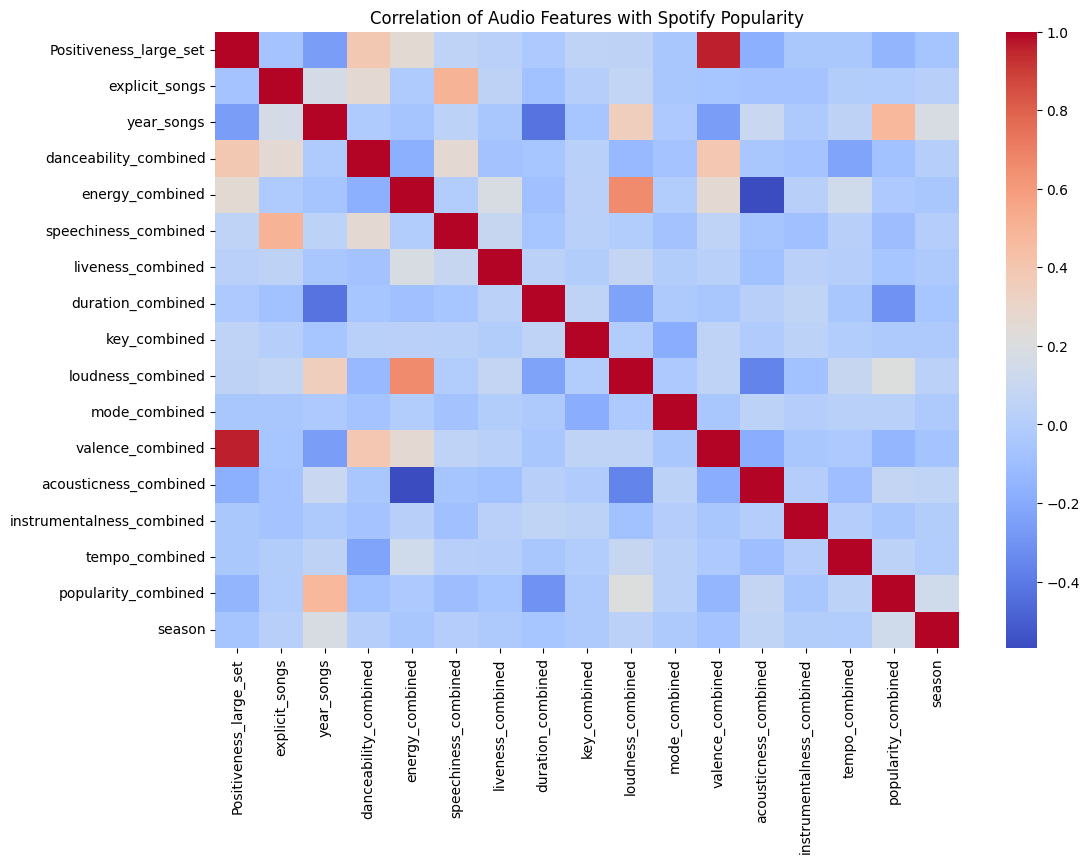

In [78]:
# To find the correlation

import seaborn as sns
import matplotlib.pyplot as plt

# Keep only numerical columns
num_df = matched.select_dtypes(include=["float64", "int64"])

# Correlation with popularity
corr = num_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation of Audio Features with Spotify Popularity")
plt.show()

__________________________________

# Modeling

OK, you have a deep understanding of your data now so you can move on to setting up your model.

In [81]:
matched.head(2)

,Positiveness_large_set,playlist_genre_spotify,playlist_subgenre_spotify,explicit_songs,year_songs,Length_large_set,Genre_large_set,Key_large_set,Explicit_large_set,danceability_combined,...,key_combined,loudness_combined,mode_combined,valence_combined,acousticness_combined,instrumentalness_combined,tempo_combined,popularity_combined,release_date_combined,season
0,13,rock,permanent wave,0,2004,4:38,rock,C Maj,No,0.306418,...,0.0,-7.550333,1.0,0.1455,0.01785,0.000366,139.942333,60.0,1999-01-01,1
1,34,rock,classic rock,0,1994,4:38,rock,F# Maj,No,0.239148,...,6.0,-9.675667,1.0,0.3705,0.66200,0.000001,149.421000,62.0,1994-11-01,4


In [90]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.metrics import make_scorer, r2_score, mean_squared_error
from sklearn.tree import DecisionTreeRegressor


df = matched.copy()

target = 'popularity_combined'
random_state = 42
n_splits = 5

def safe_onehot(handle_unknown = 'ignore'):
    try:
        return OneHotEncoder(handle_unknown = handle_unknown, sparse = False)
    except TypeError:
        return OneHotEncoder(handle_unknown = handle_unknown, sparse_output = False)

numeric_cols = df.select_dtypes(include = ['number']).columns.tolist()
if target in numeric_cols:
    numeric_cols.remove(target)

categorical_cols = df.select_dtypes(include = ['object', 'category']).columns.tolist()

for c in categorical_cols[:]:
    coerced = pd.to_numeric(df[c], errors = 'coerce')
    pct_numeric = coerced.notna().mean()
    if pct_numeric > 0.9:
        df[c] = coerced.fillna(coerced.median())
        categorical_cols.remove(c)
        numeric_cols.append(c)

max_cardinality = 200  # tweak if you want
for c in categorical_cols[:]:
    n_unique = df[c].nunique(dropna=True)
    if n_unique > max_cardinality:
        # keep top (max_cardinality - 1) categories, map others to 'other'
        top = df[c].value_counts().nlargest(max_cardinality - 1).index
        df[c] = df[c].where(df[c].isin(top), other='__other__')

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ohe = safe_onehot()

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='__missing__')),
    ('onehot', ohe)
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
], remainder='drop')


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better = False)
r2_scorer = make_scorer(r2_score)

cv = KFold(n_splits = n_splits, shuffle = True, random_state = random_state)

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha = 1.0, random_state = random_state),
    'BayesianRidge': BayesianRidge(),
    'DecisionTree': DecisionTreeRegressor(random_state = random_state),
    'KNN': KNeighborsRegressor(n_neighbors = 5, n_jobs =-1 ),
    'RandomForest': RandomForestRegressor(n_estimators = 200, n_jobs = -1, random_state = random_state),
    'GradientBoosting': GradientBoostingRegressor(random_state = random_state, n_estimators = 200),
    'HistGB': HistGradientBoostingRegressor(random_state = random_state)
}

results = []
X = df.drop(columns = [target])
y = df[target].values

for name, estimator in models.items():
    pipe = Pipeline(steps = [('preprocessor', preprocessor), ('model', estimator)])
    print(f"Evaluating: {name} ...")
    neg_rmse = cross_val_score(pipe, X, y, scoring = rmse_scorer, cv = cv, n_jobs = -1)
    r2 = cross_val_score(pipe, X, y, scoring = 'r2', cv = cv, n_jobs = -1)
    results.append({
        'model': name,
        'neg_rmse_mean': np.std(neg_rmse),
        'r2_mean': np.mean(r2),
        'r2_std': np.std(r2)
    })

res_df = pd.DataFrame(results)
res_df = res_df.sort_values('neg_rmse_mean', ascending = False).reset_index(drop = True)

print("\nCV Results:")
print(res_df[['model','r2_mean','r2_std','neg_rmse_mean']])


Evaluating: LinearRegression ...
Evaluating: Ridge ...
Evaluating: BayesianRidge ...
Evaluating: DecisionTree ...
Evaluating: KNN ...
Evaluating: RandomForest ...
Evaluating: GradientBoosting ...
Evaluating: HistGB ...

CV Results:
              model   r2_mean    r2_std  neg_rmse_mean
0  LinearRegression  0.333202  0.056657       0.392680
1             Ridge  0.348275  0.054431       0.388271
2     BayesianRidge  0.387451  0.050892       0.385978
3            HistGB  0.405349  0.047599       0.379967
4  GradientBoosting  0.406779  0.043735       0.334324
5      RandomForest  0.409591  0.036796       0.297026
6               KNN  0.272605  0.044467       0.292854
7      DecisionTree -0.159651  0.025161       0.196495


### Questions

👀 Do you need to do dimension reduction based on correlations or other reasons?

👀 Are you doing supervised or unsupervised learning? 

👀 If you are doing supervised learning, how will you set up your cross validation?

👀 Which model type will you use (regression, classification, clustering, association rule mining)?

👀 Which algorithm under your chosen model type will you use? Will you try more than one algorithm (hint, yes)?

👀 Which hyperparameters will you edit during your experiments, and across what ranges of values (see scikit-learn)?

👀 How can you set up so that your experiments are run automatically (rather than having to change the hyperparameters manually each time)?

👀 How many runs per model/hyperparameter configuration will you do?

👀 How will you output the results to evaluate them?

👀 What is one of the most important things to look for in choosing a good configuration?

👀 How will you describe your process here in words, tables and figures?

_____________________

# Evaluation and Deployment

OK, you've decided on how to describe your analysis from a modeling perspective, now you need to figure out how the results are used to answer the business question. Then, think back to how you were asked to 'deploy' the results: in the case of our class project you were asked to do a presentation and final report. Feel free to try using something like Streamlit to do a dashboard as well if you want to stretch yourself.

### Questions

👀 What did you learn about the topic you studied?

👀 What did you learn about data mining?

👀 How do you think what you learned will differ for different topics and datasets?

👀 What do you think will be similar no matter what topic you are studying?

_______________

# Final Report

Don't forget to use all of this notebook to write your final report!